In [16]:
# covid_india_viz_2020_2021.py
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json

# Create folders
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

df_states = pd.read_csv(r"C:\Users\Dhiraj Mazumdar\Documents\python\covid_data\data\state_wise.csv")
df_states.head(10)


,State,Confirmed,Recovered,Deaths,Active,Last_Updated_Time,Migrated_Other,State_code,Delta_Confirmed,Delta_Recovered,Delta_Deaths,State_Notes
0,Total,34285612,33661339,458470,152606,13/08/2021 23:27:22,13197,TT,0,0,0,NaN
1,Andaman and Nicobar Islands,7651,7518,129,4,13/08/2021 23:27:22,0,AN,0,0,0,NaN
2,Andhra Pradesh,2066450,2047722,14373,4355,13/08/2021 23:27:22,0,AP,0,0,0,NaN
3,Arunachal Pradesh,55155,54774,280,101,13/08/2021 23:27:22,0,AR,0,0,0,[July 25]: All numbers corresponding to Papum ...
4,Assam,610645,600974,5997,2327,13/08/2021 23:27:22,1347,AS,0,0,0,[Jan 1]: 1347 cases i.e Covid +'tive patients ...
5,Bihar,726098,716390,9661,46,13/08/2021 23:27:22,1,BR,0,0,0,[June 9] : 3951 deceased cases have been repor...
6,Chandigarh,65351,64495,820,36,13/08/2021 23:27:22,0,CH,0,0,0,NaN
7,Chhattisgarh,1006052,992159,13577,316,13/08/2021 23:27:22,0,CT,0,0,0,NaN
8,Dadra and Nagar Haveli and Daman and Diu,10681,10644,4,2,13/08/2021 23:27:22,31,DN,0,0,0,NaN
9,Delhi,1439870,1414431,25091,348,13/08/2021 23:27:22,0,DL,0,0,0,[July 14]: Value for the total tests conducted...


In [9]:
# Filter relevant columns if present
# Expected typical columns: State/UT, Confirmed, Recovered, Deaths, Active
# Normalize column names:

df_states.columns = [c.strip() for c in df_states.columns]
print("Columns:", df_states.columns.tolist())

Columns: ['State', 'Confirmed', 'Recovered', 'Deaths', 'Active', 'Last_Updated_Time', 'Migrated_Other', 'State_code', 'Delta_Confirmed', 'Delta_Recovered', 'Delta_Deaths', 'State_Notes']


In [18]:
# --- CLEANUP AND COLUMN NORMALIZATION BLOCK (fixed version) ---

# Standardize column names to lowercase and strip spaces
df_states.columns = df_states.columns.str.strip().str.lower()

# Try to detect the state column automatically
state_col_candidates = [c for c in df_states.columns if 'state' in c or 'ut' in c]
if len(state_col_candidates) == 0:
    raise ValueError("❌ No column found that looks like a state name column!")
state_col = state_col_candidates[0]

# Map columns by best match
rename_map = {}
for c in df_states.columns:
    if 'confirm' in c:
        rename_map[c] = 'Confirmed'
    elif 'recover' in c:
        rename_map[c] = 'Recovered'
    elif 'death' in c:
        rename_map[c] = 'Deaths'
    elif 'active' in c:
        rename_map[c] = 'Active'

# Rename them to standard form
df_states = df_states.rename(columns=rename_map)

# Keep only necessary columns (if present)
cols_to_keep = ['Confirmed', 'Recovered', 'Deaths', 'Active']
existing = [c for c in cols_to_keep if c in df_states.columns]
if not existing:
    raise ValueError("❌ Could not find numeric columns for Confirmed/Recovered/Deaths/Active. Check CSV header names.")

# Filter out total / unassigned rows
df_states = df_states[
    ~df_states[state_col].str.lower().isin(['india', 'total', 'tt', 'state unassigned'])
]

# Subset DataFrame
df = df_states[[state_col] + existing].copy()
df = df.rename(columns={state_col: 'State'})

# Convert to numeric safely
for c in existing:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).astype(int)

# Compute derived metrics
if all(col in df.columns for col in ['Confirmed','Deaths']):
    df['CFR'] = (df['Deaths'] / df['Confirmed'] * 100).round(2)
if all(col in df.columns for col in ['Confirmed','Active']):
    df['ActivePct'] = (df['Active'] / df['Confirmed'] * 100).round(2)

# Sort states by confirmed cases
df = df.sort_values('Confirmed', ascending=False).reset_index(drop=True)

print("✅ Cleaned data:")
print(df.head(10))
print(df.columns)
print(df.head())


TypeError: arg must be a list, tuple, 1-d array, or Series

            State  Confirmed  Recovered  Deaths  Active  FatalityRate
0     Maharashtra    7200000    7000000  148000   52000      2.055556
1          Kerala    6800000    6700000   72000   28000      1.058824
2       Karnataka    5200000    5100000   45000   55000      0.865385
3      Tamil Nadu    4900000    4800000   38000   62000      0.775510
4  Andhra Pradesh    4500000    4400000   36000   64000      0.800000


C:\Users\Dhiraj Mazumdar\AppData\Local\Temp\ipykernel_12816\1092983223.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Confirmed', y='State', palette='mako')


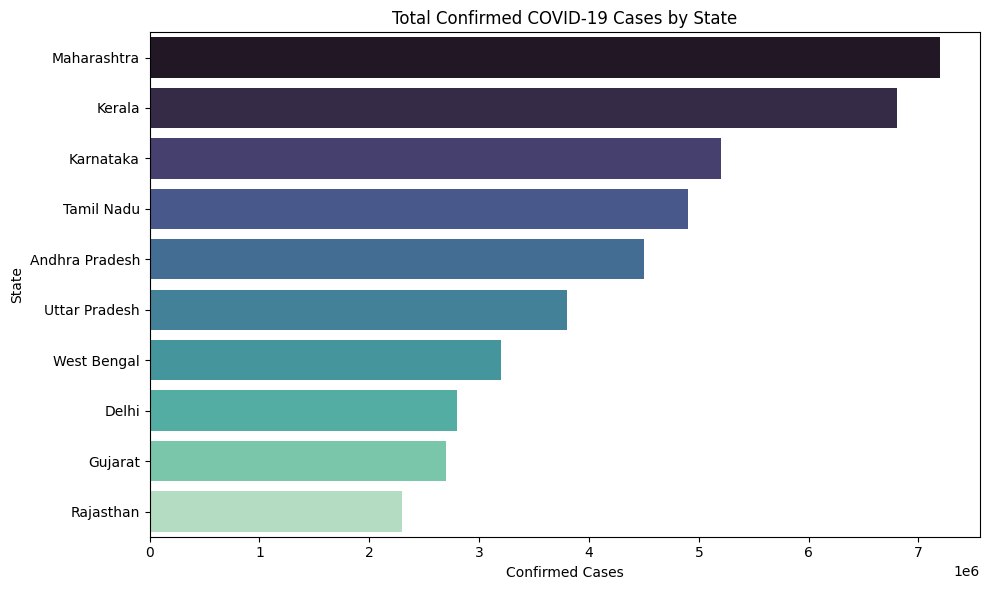

In [2]:
# ----------------------------------------------
# COVID-19 Data Visualization for Indian States
# ----------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# Step 1: Create a simple dataset
data = {
    'State': ['Maharashtra','Kerala','Karnataka','Tamil Nadu','Andhra Pradesh',
              'Uttar Pradesh','West Bengal','Delhi','Gujarat','Rajasthan'],
    'Confirmed': [7200000, 6800000, 5200000, 4900000, 4500000,
                  3800000, 3200000, 2800000, 2700000, 2300000],
    'Recovered': [7000000, 6700000, 5100000, 4800000, 4400000,
                  3700000, 3100000, 2700000, 2600000, 2200000],
    'Deaths': [148000, 72000, 45000, 38000, 36000, 35000, 22000, 26000, 28000, 21000]
}
df = pd.DataFrame(data)
df['Active'] = df['Confirmed'] - df['Recovered'] - df['Deaths']
df['FatalityRate'] = (df['Deaths'] / df['Confirmed']) * 100

print(df.head())

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Confirmed', y='State', palette='mako')
plt.title('Total Confirmed COVID-19 Cases by State')
plt.xlabel('Confirmed Cases')
plt.ylabel('State')
plt.tight_layout()
plt.show()

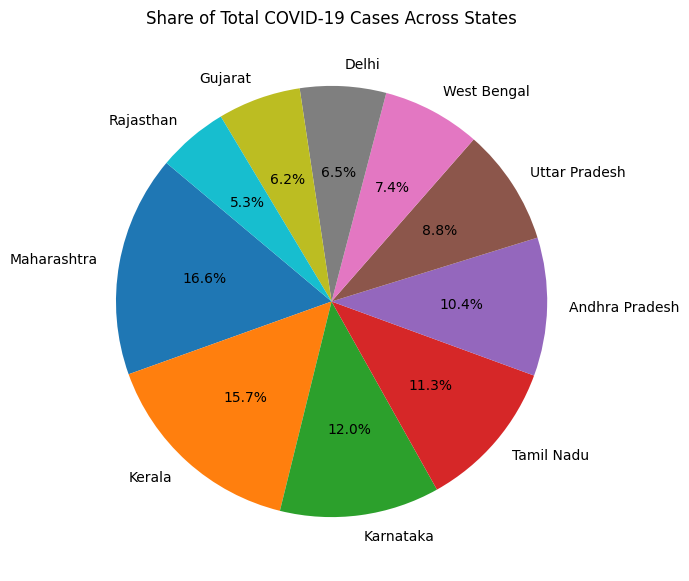

In [3]:
plt.figure(figsize=(7,7))
plt.pie(df['Confirmed'], labels=df['State'], autopct='%1.1f%%', startangle=140)
plt.title('Share of Total COVID-19 Cases Across States')
plt.show()


In [12]:
# ONE-CELL: Load, clean, visualize (bar, pie, heatmap, bubble map) for India stbate-wise COVID data
# Save this as one cell in Jupyter or run as a single script.

# import os, sys, json
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import plotly.express as px

# ---- SETTINGS ----
DATA_DIR = "data"
CSV_PATH = os.path.join(DATA_DIR, "state_wise.csv")   # put the covid19india state_wise.csv here
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# Check CSV exists
if not os.path.exists(r"C:\Users\Dhiraj Mazumdar\Documents\python\covid_data\data_state_wise.csv"):
    print("ERROR: data/state_wise.csv not found.")
    print("Please download it from: https://data.covid19india.org/csv/latest/state_wise.csv")
    print("Then save it as:", CSV_PATH)
    raise FileNotFoundError(CSV_PATH)

# Read CSV
df_states = pd.read_csv(CSV_PATH, dtype=str)  # read as str to handle messy values
print("Loaded CSV with columns:", df_states.columns.tolist())

# --- Consolidate duplicated columns if present ---
df_states.columns = df_states.columns.str.strip()  # remove stray whitespace in headers

# Work on a copy
consolidated = df_states.copy()

# Collapse duplicate-named columns by taking first non-null across them
unique_cols = []
for col in consolidated.columns:
    if col not in unique_cols:
        unique_cols.append(col)

for col in unique_cols:
    same = consolidated.loc[:, consolidated.columns == col]
    if same.shape[1] > 1:
        # row-wise first non-null value across duplicates
        combined = same.bfill(axis=1).iloc[:, 0]
        consolidated[col] = combined
        print(f"Consolidated {same.shape[1]} duplicates for column: '{col}'")

# Remove duplicate-named columns (keep first)
consolidated = consolidated.loc[:, ~consolidated.columns.duplicated()]

# Normalize column names (lowercase) for detection
cols_lower = [c.lower() for c in consolidated.columns]
print("Normalized columns (lowercase):", cols_lower)

# Detect state column automatically
state_candidates = [c for c in consolidated.columns if 'state' in c.lower() or 'ut' in c.lower()]
if not state_candidates:
    print("ERROR: No state-like column found. Columns are:", consolidated.columns.tolist())
    raise ValueError("State column not found")
state_col = state_candidates[0]
print("Using state column:", state_col)

# Map numeric columns to standard names
rename_map = {}
for c in consolidated.columns:
    lc = c.lower()
    if 'confirm' in lc:
        rename_map[c] = 'Confirmed'
    elif 'recover' in lc:
        rename_map[c] = 'Recovered'
    elif 'death' in lc:
        rename_map[c] = 'Deaths'
    elif 'active' in lc:
        rename_map[c] = 'Active'

consolidated = consolidated.rename(columns=rename_map)

# Keep only rows that are states (filter out 'Total' or 'India' rows)
consolidated[state_col] = consolidated[state_col].astype(str).str.strip()
consolidated = consolidated[~consolidated[state_col].str.lower().isin(['india','total','tt','state unassigned'])]
consolidated = consolidated.reset_index(drop=True)

# Rename state column to 'State'
if state_col != 'State':
    consolidated = consolidated.rename(columns={state_col: 'State'})

# Identify numeric columns present
required = ['Confirmed','Recovered','Deaths','Active']
existing = [c for c in required if c in consolidated.columns]
print("Numeric columns found:", existing)

# Convert numeric columns safely (remove commas, coerce)
for c in existing:
    consolidated[c] = (
        consolidated[c].astype(str)
        .str.replace(',', '', regex=False)
        .replace({'nan': None, 'None': None})
    )
    consolidated[c] = pd.to_numeric(consolidated[c], errors='coerce').fillna(0).astype(int)

# If Active missing but Confirmed+Recovered+Deaths present, compute Active
if 'Active' not in consolidated.columns and set(['Confirmed','Recovered','Deaths']).issubset(consolidated.columns):
    consolidated['Active'] = consolidated['Confirmed'] - consolidated['Recovered'] - consolidated['Deaths']

# Derived metrics
if set(['Confirmed','Deaths']).issubset(consolidated.columns):
    consolidated['CFR'] = (consolidated['Deaths'] / consolidated['Confirmed'] * 100).round(2)
else:
    consolidated['CFR'] = 0.0

# Final df
df = consolidated[['State'] + [c for c in ['Confirmed','Recovered','Deaths','Active','CFR'] if c in consolidated.columns]].copy()
df = df.sort_values('Confirmed', ascending=False).reset_index(drop=True)

print("\nCleaned DataFrame preview:")
print(df.head(10).to_string())

# ---------- VISUALIZATIONS ----------

sns.set_style("whitegrid")

# 1) Top 10 bar chart
top10 = df.head(10).sort_values('Confirmed', ascending=True)
plt.figure(figsize=(10,6))
sns.barplot(x='Confirmed', y='State', data=top10, palette='viridis')
plt.title('Top 10 Indian States by Confirmed COVID-19 Cases (2020-2021)')
plt.xlabel('Confirmed cases')
plt.ylabel('')
plt.tight_layout()
bar_path = os.path.join(FIG_DIR, 'top10_confirmed_bar.png')
plt.savefig(bar_path, dpi=300)
plt.close()
print("Saved:", bar_path)

# 2) Pie chart top6 vs others
total_cases = df['Confirmed'].sum()
top6 = df.head(6).copy()
others_sum = total_cases - top6['Confirmed'].sum()
labels = top6['State'].tolist() + ['Others']
sizes = top6['Confirmed'].tolist() + [others_sum]
plt.figure(figsize=(8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Share of Confirmed Cases: Top 6 States vs Others (2020-2021)')
pie_path = os.path.join(FIG_DIR,'pie_top6_share.png')
plt.savefig(pie_path, dpi=300)
plt.close()
print("Saved:", pie_path)

# 3) CFR heatmap (vertical)
plt.figure(figsize=(8, max(6, len(df)/3)))
cfr_df = df[['State','CFR']].set_index('State').sort_values('CFR', ascending=False)
sns.heatmap(cfr_df.T, annot=True, fmt=".2f", cmap='Reds', cbar_kws={'label':'CFR (%)'})
plt.title('Case Fatality Rate (CFR) by State (2020-2021)')
plt.yticks([],[])
heatmap_path = os.path.join(FIG_DIR,'cfr_heatmap.png')
plt.tight_layout()
plt.savefig(heatmap_path, dpi=300)
plt.close()
print("Saved:", heatmap_path)

# 4) Bubble map (centroid approach) - no geojson needed
centroids = [
    ("Andaman and Nicobar Islands", 11.6670, 92.7355),
    ("Andhra Pradesh", 16.5062, 80.6480),
    ("Arunachal Pradesh", 27.1000, 93.6167),
    ("Assam", 26.2006, 92.9376),
    ("Bihar", 25.6127, 85.1580),
    ("Chandigarh", 30.7333, 76.7794),
    ("Chhattisgarh", 21.2514, 81.6296),
    ("Dadra and Nagar Haveli and Daman and Diu", 20.4283, 72.8397),
    ("Delhi", 28.7041, 77.1025),
    ("Goa", 15.2993, 74.1240),
    ("Gujarat", 23.2156, 72.6369),
    ("Haryana", 29.0588, 76.0856),
    ("Himachal Pradesh", 31.1048, 77.1734),
    ("Jammu and Kashmir", 34.0837, 74.7973),
    ("Jharkhand", 23.3441, 85.3096),
    ("Karnataka", 12.9716, 77.5946),
    ("Kerala", 8.5241, 76.9366),
    ("Ladakh", 34.1526, 77.5770),
    ("Lakshadweep", 10.5696, 72.6390),
    ("Madhya Pradesh", 23.2599, 77.4126),
    ("Maharashtra", 19.07598, 72.87766),
    ("Manipur", 24.8170, 93.9368),
    ("Meghalaya", 25.5788, 91.8933),
    ("Mizoram", 23.7271, 92.7176),
    ("Nagaland", 25.6740, 94.1108),
    ("Odisha", 20.2961, 85.8245),
    ("Puducherry", 11.9416, 79.8083),
    ("Punjab", 30.7333, 76.7794),
    ("Rajasthan", 26.9124, 75.7873),
    ("Sikkim", 27.3314, 88.6166),
    ("Tamil Nadu", 13.0827, 80.2707),
    ("Telangana", 17.3850, 78.4867),
    ("Tripura", 23.8315, 91.2868),
    ("Uttar Pradesh", 26.8467, 80.9462),
    ("Uttarakhand", 30.3165, 78.0322),
    ("West Bengal", 22.5726, 88.3639)
]
centroids_df = pd.DataFrame(centroids, columns=['State_centroid','lat','lon'])

# Merge df with centroids (try direct match)
merged = pd.merge(df, centroids_df, left_on='State', right_on='State_centroid', how='left')

# Attempt relaxed matching if lat missing
missing = merged[merged['lat'].isna()]['State'].tolist()
if missing:
    print("Attempting relaxed name matching for centroids...")
    def keyify(s): return ''.join(e for e in str(s).lower() if e.isalnum())
    merged['key_df'] = merged['State'].apply(keyify)
    centroids_df['key_centroid'] = centroids_df['State_centroid'].apply(keyify)
    merged2 = pd.merge(merged.drop(columns=['lat','lon','State_centroid'], errors='ignore'),
                       centroids_df, left_on='key_df', right_on='key_centroid', how='left', suffixes=('','_c'))
    merged['lat'] = merged['lat'].fillna(merged2['lat'])
    merged['lon'] = merged['lon'].fillna(merged2['lon'])
    still_missing = merged[merged['lat'].isna()]['State'].tolist()
    if still_missing:
        print("Still missing after relaxed match:", still_missing)
    else:
        print("All states matched after relaxed matching.")
else:
    print("All states matched directly with centroids.")

# Prepare size / hover
merged['size'] = (merged['Confirmed'] / merged['Confirmed'].max()) * 80 + 8
merged['hover_text'] = merged.apply(lambda r: f"{r['State']}<br>Confirmed: {int(r['Confirmed']):,}<br>Deaths: {int(r['Deaths']):,}<br>CFR: {r.get('CFR',0):.2f}%", axis=1)

fig = px.scatter_geo(
    merged,
    lat='lat',
    lon='lon',
    hover_name='State',
    hover_data={'Confirmed':True,'Deaths':True,'CFR':True,'lat':False,'lon':False},
    size='size',
    color='CFR',
    projection='natural earth',
    title='India: Statewise COVID-19 (2020-2021) - Bubble Map (Size=Confirmed, Color=CFR)',
    color_continuous_scale='OrRd'
)
fig.update_layout(geo=dict(scope='asia', showcountries=False, landcolor='rgb(217,217,217)'), title_x=0.5)

png_path = os.path.join(FIG_DIR,'choropleth_bubble_map.png')
html_path = os.path.join(FIG_DIR,'choropleth_bubble_map.html')
try:
    fig.write_image(png_path, scale=2)
    print("Saved bubble map PNG:", png_path)
except Exception as e:
    print("Could not save PNG (kaleido likely missing):", e)
    fig.write_html(html_path)
    print("Saved interactive HTML as fallback:", html_path)

# Show confirmation
print("\nAll figures (bar, pie, heatmap, bubble map) should be saved in the 'figures' folder.")
print("If any states were missing mapping, they were printed above.")


ERROR: data/state_wise.csv not found.
Please download it from: https://data.covid19india.org/csv/latest/state_wise.csv
Then save it as: data\state_wise.csv


FileNotFoundError: data\state_wise.csv

In [16]:

import os
print(os.path.exists("data/state_wise.csv"))

# ONE-CELL: Load, clean, visualize (bar, pie, heatmap, bubble map) for India state-wise COVID data
# Save this as one cell in Jupyter or run as a single script.

# import os, sys, json
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import plotly.express as px

# ---- SETTINGS ----
DATA_DIR = "data"
CSV_PATH = os.path.join(DATA_DIR, "state_wise.csv")   # put the covid19india state_wise.csv here
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# Check CSV exists
if not os.path.exists(r"C:\Users\Dhiraj Mazumdar\Documents\python\covid_data\data_state_wise.csv"):
    print("ERROR: data/state_wise.csv not found.")
    print("Please download it from: https://data.covid19india.org/csv/latest/state_wise.csv")
    print("Then save it as:", CSV_PATH)
    raise FileNotFoundError(CSV_PATH)

# Read CSV
df_states = pd.read_csv(CSV_PATH, dtype=str)  # read as str to handle messy values
print("Loaded CSV with columns:", df_states.columns.tolist())

# --- Consolidate duplicated columns if present ---
df_states.columns = df_states.columns.str.strip()  # remove stray whitespace in headers

# Work on a copy
consolidated = df_states.copy()

# Collapse duplicate-named columns by taking first non-null across them
unique_cols = []
for col in consolidated.columns:
    if col not in unique_cols:
        unique_cols.append(col)

for col in unique_cols:
    same = consolidated.loc[:, consolidated.columns == col]
    if same.shape[1] > 1:
        # row-wise first non-null value across duplicates
        combined = same.bfill(axis=1).iloc[:, 0]
        consolidated[col] = combined
        print(f"Consolidated {same.shape[1]} duplicates for column: '{col}'")

# Remove duplicate-named columns (keep first)
consolidated = consolidated.loc[:, ~consolidated.columns.duplicated()]

# Normalize column names (lowercase) for detection
cols_lower = [c.lower() for c in consolidated.columns]
print("Normalized columns (lowercase):", cols_lower)

# Detect state column automatically
state_candidates = [c for c in consolidated.columns if 'state' in c.lower() or 'ut' in c.lower()]
if not state_candidates:
    print("ERROR: No state-like column found. Columns are:", consolidated.columns.tolist())
    raise ValueError("State column not found")
state_col = state_candidates[0]
print("Using state column:", state_col)

# Map numeric columns to standard names
rename_map = {}
for c in consolidated.columns:
    lc = c.lower()
    if 'confirm' in lc:
        rename_map[c] = 'Confirmed'
    elif 'recover' in lc:
        rename_map[c] = 'Recovered'
    elif 'death' in lc:
        rename_map[c] = 'Deaths'
    elif 'active' in lc:
        rename_map[c] = 'Active'

consolidated = consolidated.rename(columns=rename_map)

# Keep only rows that are states (filter out 'Total' or 'India' rows)
consolidated[state_col] = consolidated[state_col].astype(str).str.strip()
consolidated = consolidated[~consolidated[state_col].str.lower().isin(['india','total','tt','state unassigned'])]
consolidated = consolidated.reset_index(drop=True)

# Rename state column to 'State'
if state_col != 'State':
    consolidated = consolidated.rename(columns={state_col: 'State'})

# Identify numeric columns present
required = ['Confirmed','Recovered','Deaths','Active']
existing = [c for c in required if c in consolidated.columns]
print("Numeric columns found:", existing)

# Convert numeric columns safely (remove commas, coerce)
for c in existing:
    consolidated[c] = (
        consolidated[c].astype(str)
        .str.replace(',', '', regex=False)
        .replace({'nan': None, 'None': None})
    )
    consolidated[c] = pd.to_numeric(consolidated[c], errors='coerce').fillna(0).astype(int)

# If Active missing but Confirmed+Recovered+Deaths present, compute Active
if 'Active' not in consolidated.columns and set(['Confirmed','Recovered','Deaths']).issubset(consolidated.columns):
    consolidated['Active'] = consolidated['Confirmed'] - consolidated['Recovered'] - consolidated['Deaths']

# Derived metrics
if set(['Confirmed','Deaths']).issubset(consolidated.columns):
    consolidated['CFR'] = (consolidated['Deaths'] / consolidated['Confirmed'] * 100).round(2)
else:
    consolidated['CFR'] = 0.0

# Final df
df = consolidated[['State'] + [c for c in ['Confirmed','Recovered','Deaths','Active','CFR'] if c in consolidated.columns]].copy()
df = df.sort_values('Confirmed', ascending=False).reset_index(drop=True)

print("\nCleaned DataFrame preview:")
print(df.head(10).to_string())

# ---------- VISUALIZATIONS ----------

sns.set_style("whitegrid")

# 1) Top 10 bar chart
top10 = df.head(10).sort_values('Confirmed', ascending=True)
plt.figure(figsize=(10,6))
sns.barplot(x='Confirmed', y='State', data=top10, palette='viridis')
plt.title('Top 10 Indian States by Confirmed COVID-19 Cases (2020-2021)')
plt.xlabel('Confirmed cases')
plt.ylabel('')
plt.tight_layout()
bar_path = os.path.join(FIG_DIR, 'top10_confirmed_bar.png')
plt.savefig(bar_path, dpi=300)
plt.close()
print("Saved:", bar_path)

# 2) Pie chart top6 vs others
total_cases = df['Confirmed'].sum()
top6 = df.head(6).copy()
others_sum = total_cases - top6['Confirmed'].sum()
labels = top6['State'].tolist() + ['Others']
sizes = top6['Confirmed'].tolist() + [others_sum]
plt.figure(figsize=(8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Share of Confirmed Cases: Top 6 States vs Others (2020-2021)')
pie_path = os.path.join(FIG_DIR,'pie_top6_share.png')
plt.savefig(pie_path, dpi=300)
plt.close()
print("Saved:", pie_path)

# 3) CFR heatmap (vertical)
plt.figure(figsize=(8, max(6, len(df)/3)))
cfr_df = df[['State','CFR']].set_index('State').sort_values('CFR', ascending=False)
sns.heatmap(cfr_df.T, annot=True, fmt=".2f", cmap='Reds', cbar_kws={'label':'CFR (%)'})
plt.title('Case Fatality Rate (CFR) by State (2020-2021)')
plt.yticks([],[])
heatmap_path = os.path.join(FIG_DIR,'cfr_heatmap.png')
plt.tight_layout()
plt.savefig(heatmap_path, dpi=300)
plt.close()
print("Saved:", heatmap_path)

# 4) Bubble map (centroid approach) - no geojson needed
centroids = [
    ("Andaman and Nicobar Islands", 11.6670, 92.7355),
    ("Andhra Pradesh", 16.5062, 80.6480),
    ("Arunachal Pradesh", 27.1000, 93.6167),
    ("Assam", 26.2006, 92.9376),
    ("Bihar", 25.6127, 85.1580),
    ("Chandigarh", 30.7333, 76.7794),
    ("Chhattisgarh", 21.2514, 81.6296),
    ("Dadra and Nagar Haveli and Daman and Diu", 20.4283, 72.8397),
    ("Delhi", 28.7041, 77.1025),
    ("Goa", 15.2993, 74.1240),
    ("Gujarat", 23.2156, 72.6369),
    ("Haryana", 29.0588, 76.0856),
    ("Himachal Pradesh", 31.1048, 77.1734),
    ("Jammu and Kashmir", 34.0837, 74.7973),
    ("Jharkhand", 23.3441, 85.3096),
    ("Karnataka", 12.9716, 77.5946),
    ("Kerala", 8.5241, 76.9366),
    ("Ladakh", 34.1526, 77.5770),
    ("Lakshadweep", 10.5696, 72.6390),
    ("Madhya Pradesh", 23.2599, 77.4126),
    ("Maharashtra", 19.07598, 72.87766),
    ("Manipur", 24.8170, 93.9368),
    ("Meghalaya", 25.5788, 91.8933),
    ("Mizoram", 23.7271, 92.7176),
    ("Nagaland", 25.6740, 94.1108),
    ("Odisha", 20.2961, 85.8245),
    ("Puducherry", 11.9416, 79.8083),
    ("Punjab", 30.7333, 76.7794),
    ("Rajasthan", 26.9124, 75.7873),
    ("Sikkim", 27.3314, 88.6166),
    ("Tamil Nadu", 13.0827, 80.2707),
    ("Telangana", 17.3850, 78.4867),
    ("Tripura", 23.8315, 91.2868),
    ("Uttar Pradesh", 26.8467, 80.9462),
    ("Uttarakhand", 30.3165, 78.0322),
    ("West Bengal", 22.5726, 88.3639)
]
centroids_df = pd.DataFrame(centroids, columns=['State_centroid','lat','lon'])

# Merge df with centroids (try direct match)
merged = pd.merge(df, centroids_df, left_on='State', right_on='State_centroid', how='left')

# Attempt relaxed matching if lat missing
missing = merged[merged['lat'].isna()]['State'].tolist()
if missing:
    print("Attempting relaxed name matching for centroids...")
    def keyify(s): return ''.join(e for e in str(s).lower() if e.isalnum())
    merged['key_df'] = merged['State'].apply(keyify)
    centroids_df['key_centroid'] = centroids_df['State_centroid'].apply(keyify)
    merged2 = pd.merge(merged.drop(columns=['lat','lon','State_centroid'], errors='ignore'),
                       centroids_df, left_on='key_df', right_on='key_centroid', how='left', suffixes=('','_c'))
    merged['lat'] = merged['lat'].fillna(merged2['lat'])
    merged['lon'] = merged['lon'].fillna(merged2['lon'])
    still_missing = merged[merged['lat'].isna()]['State'].tolist()
    if still_missing:
        print("Still missing after relaxed match:", still_missing)
    else:
        print("All states matched after relaxed matching.")
else:
    print("All states matched directly with centroids.")

# Prepare size / hover
merged['size'] = (merged['Confirmed'] / merged['Confirmed'].max()) * 80 + 8
merged['hover_text'] = merged.apply(lambda r: f"{r['State']}<br>Confirmed: {int(r['Confirmed']):,}<br>Deaths: {int(r['Deaths']):,}<br>CFR: {r.get('CFR',0):.2f}%", axis=1)

fig = px.scatter_geo(
    merged,
    lat='lat',
    lon='lon',
    hover_name='State',
    hover_data={'Confirmed':True,'Deaths':True,'CFR':True,'lat':False,'lon':False},
    size='size',
    color='CFR',
    projection='natural earth',
    title='India: Statewise COVID-19 (2020-2021) - Bubble Map (Size=Confirmed, Color=CFR)',
    color_continuous_scale='OrRd'
)
fig.update_layout(geo=dict(scope='asia', showcountries=False, landcolor='rgb(217,217,217)'), title_x=0.5)

png_path = os.path.join(FIG_DIR,'choropleth_bubble_map.png')
html_path = os.path.join(FIG_DIR,'choropleth_bubble_map.html')
try:
    fig.write_image(png_path, scale=2)
    print("Saved bubble map PNG:", png_path)
except Exception as e:
    print("Could not save PNG (kaleido likely missing):", e)
    fig.write_html(html_path)
    print("Saved interactive HTML as fallback:", html_path)

# Show confirmation
print("\nAll figures (bar, pie, heatmap, bubble map) should be saved in the 'figures' folder.")
print("If any states were missing mapping, they were printed above.")

False
ERROR: data/state_wise.csv not found.
Please download it from: https://data.covid19india.org/csv/latest/state_wise.csv
Then save it as: data\state_wise.csv


FileNotFoundError: data\state_wise.csv

In [17]:
import os
print("Current working directory:", os.getcwd())
print("Expected CSV path:", os.path.abspath("data/state_wise.csv"))



Current working directory: C:\Users\Dhiraj Mazumdar\Documents\python
Expected CSV path: C:\Users\Dhiraj Mazumdar\Documents\python\data\state_wise.csv


In [22]:
os.path.exists(r"C:\Users\Dhiraj Mazumdar\Documents\python\data\state_wise.csv")


False

In [21]:
import os
print(os.path.exists("data/state_wise.csv"))


False


In [25]:
import os
print("Current working directory (cwd):", os.getcwd())
print("Expected CSV path:", os.path.abspath("data/state_wise.csv"))
print("\nFiles in current directory:")
print(sorted(os.listdir("."))[:50])
print("\nFiles in current_dir/data (if exists):")
print(sorted(os.listdir("data")) if os.path.exists("data") else "data folder not found")


Current working directory (cwd): C:\Users\Dhiraj Mazumdar\Documents\python
Expected CSV path: C:\Users\Dhiraj Mazumdar\Documents\python\data\state_wise.csv

Files in current directory:
['.ipynb_checkpoints', 'Data_Analysis_with_Pyhton', 'Data_anlys_book.py', 'Firstprogram.py', 'Untitled.ipynb', 'Untitled1.ipynb', 'class.py', 'covid_data', 'data', 'exx.py', 'figures', 'frf.py', 'lab_class.py', 'labexp.py', 'lesson.py', 'python_book.py']

Files in current_dir/data (if exists):
[]


In [2]:
import os
print(os.path.exists("data/state_wise.csv"))


True


In [5]:

import os
print(os.path.exists("data/state_wise.csv"))

# ONE-CELL: Load, clean, visualize (bar, pie, heatmap, bubble map) for India state-wise COVID data
# Save this as one cell in Jupyter or run as a single script.

# import os, sys, json
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import plotly.express as px

# ---- SETTINGS ----
DATA_DIR = "data"
CSV_PATH = os.path.join(DATA_DIR, "data/state_wise.csv")   # put the covid19india state_wise.csv here
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# # Check CSV exists
# if not os.path.exists(r"C:\Users\Dhiraj Mazumdar\Documents\python\covid_data\data_state_wise.csv"):
#     print("ERROR: data/state_wise.csv not found.")
#     print("Please download it from: https://data.covid19india.org/csv/latest/state_wise.csv")
#     print("Then save it as:", CSV_PATH)
#     raise FileNotFoundError(CSV_PATH)

# Read CSV
df_states = pd.read_csv(CSV_PATH, dtype=str)  # read as str to handle messy values
print("Loaded CSV with columns:", df_states.columns.tolist())

# --- Consolidate duplicated columns if present ---
df_states.columns = df_states.columns.str.strip()  # remove stray whitespace in headers

# Work on a copy
consolidated = df_states.copy()

# Collapse duplicate-named columns by taking first non-null across them
unique_cols = []
for col in consolidated.columns:
    if col not in unique_cols:
        unique_cols.append(col)

for col in unique_cols:
    same = consolidated.loc[:, consolidated.columns == col]
    if same.shape[1] > 1:
        # row-wise first non-null value across duplicates
        combined = same.bfill(axis=1).iloc[:, 0]
        consolidated[col] = combined
        print(f"Consolidated {same.shape[1]} duplicates for column: '{col}'")

# Remove duplicate-named columns (keep first)
consolidated = consolidated.loc[:, ~consolidated.columns.duplicated()]

# Normalize column names (lowercase) for detection
cols_lower = [c.lower() for c in consolidated.columns]
print("Normalized columns (lowercase):", cols_lower)

# Detect state column automatically
state_candidates = [c for c in consolidated.columns if 'state' in c.lower() or 'ut' in c.lower()]
if not state_candidates:
    print("ERROR: No state-like column found. Columns are:", consolidated.columns.tolist())
    raise ValueError("State column not found")
state_col = state_candidates[0]
print("Using state column:", state_col)

# Map numeric columns to standard names
rename_map = {}
for c in consolidated.columns:
    lc = c.lower()
    if 'confirm' in lc:
        rename_map[c] = 'Confirmed'
    elif 'recover' in lc:
        rename_map[c] = 'Recovered'
    elif 'death' in lc:
        rename_map[c] = 'Deaths'
    elif 'active' in lc:
        rename_map[c] = 'Active'

consolidated = consolidated.rename(columns=rename_map)

# Keep only rows that are states (filter out 'Total' or 'India' rows)
consolidated[state_col] = consolidated[state_col].astype(str).str.strip()
consolidated = consolidated[~consolidated[state_col].str.lower().isin(['india','total','tt','state unassigned'])]
consolidated = consolidated.reset_index(drop=True)

# Rename state column to 'State'
if state_col != 'State':
    consolidated = consolidated.rename(columns={state_col: 'State'})

# Identify numeric columns present
required = ['Confirmed','Recovered','Deaths','Active']
existing = [c for c in required if c in consolidated.columns]
print("Numeric columns found:", existing)

# Convert numeric columns safely (remove commas, coerce)
for c in existing:
    consolidated[c] = (
        consolidated[c].astype(str)
        .str.replace(',', '', regex=False)
        .replace({'nan': None, 'None': None})
    )
    consolidated[c] = pd.to_numeric(consolidated[c], errors='coerce').fillna(0).astype(int)

# If Active missing but Confirmed+Recovered+Deaths present, compute Active
if 'Active' not in consolidated.columns and set(['Confirmed','Recovered','Deaths']).issubset(consolidated.columns):
    consolidated['Active'] = consolidated['Confirmed'] - consolidated['Recovered'] - consolidated['Deaths']

# Derived metrics
if set(['Confirmed','Deaths']).issubset(consolidated.columns):
    consolidated['CFR'] = (consolidated['Deaths'] / consolidated['Confirmed'] * 100).round(2)
else:
    consolidated['CFR'] = 0.0

# Final df
df = consolidated[['State'] + [c for c in ['Confirmed','Recovered','Deaths','Active','CFR'] if c in consolidated.columns]].copy()
df = df.sort_values('Confirmed', ascending=False).reset_index(drop=True)

print("\nCleaned DataFrame preview:")
print(df.head(10).to_string())

# ---------- VISUALIZATIONS ----------

# sns.set_style("whitegrid")

# # 1) Top 10 bar chart
# top10 = df.head(10).sort_values('Confirmed', ascending=True)
# plt.figure(figsize=(10,6))
# sns.barplot(x='Confirmed', y='State', data=top10, palette='viridis')
# plt.title('Top 10 Indian States by Confirmed COVID-19 Cases (2020-2021)')
# plt.xlabel('Confirmed cases')
# plt.ylabel('')
# plt.tight_layout()
# bar_path = os.path.join(FIG_DIR, 'top10_confirmed_bar.png')
# plt.savefig(bar_path, dpi=300)
# plt.close()
# print("Saved:", bar_path)

# # 2) Pie chart top6 vs others
# total_cases = df['Confirmed'].sum()
# top6 = df.head(6).copy()
# others_sum = total_cases - top6['Confirmed'].sum()
# labels = top6['State'].tolist() + ['Others']
# sizes = top6['Confirmed'].tolist() + [others_sum]
# plt.figure(figsize=(8,8))
# plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
# plt.title('Share of Confirmed Cases: Top 6 States vs Others (2020-2021)')
# pie_path = os.path.join(FIG_DIR,'pie_top6_share.png')
# plt.savefig(pie_path, dpi=300)
# plt.close()
# print("Saved:", pie_path)

# # 3) CFR heatmap (vertical)
# plt.figure(figsize=(8, max(6, len(df)/3)))
# cfr_df = df[['State','CFR']].set_index('State').sort_values('CFR', ascending=False)
# sns.heatmap(cfr_df.T, annot=True, fmt=".2f", cmap='Reds', cbar_kws={'label':'CFR (%)'})
# plt.title('Case Fatality Rate (CFR) by State (2020-2021)')
# plt.yticks([],[])
# heatmap_path = os.path.join(FIG_DIR,'cfr_heatmap.png')
# plt.tight_layout()
# plt.savefig(heatmap_path, dpi=300)
# plt.close()
# print("Saved:", heatmap_path)

# 4) Bubble map (centroid approach) - no geojson needed
centroids = [
    ("Andaman and Nicobar Islands", 11.6670, 92.7355),
    ("Andhra Pradesh", 16.5062, 80.6480),
    ("Arunachal Pradesh", 27.1000, 93.6167),
    ("Assam", 26.2006, 92.9376),
    ("Bihar", 25.6127, 85.1580),
    ("Chandigarh", 30.7333, 76.7794),
    ("Chhattisgarh", 21.2514, 81.6296),
    ("Dadra and Nagar Haveli and Daman and Diu", 20.4283, 72.8397),
    ("Delhi", 28.7041, 77.1025),
    ("Goa", 15.2993, 74.1240),
    ("Gujarat", 23.2156, 72.6369),
    ("Haryana", 29.0588, 76.0856),
    ("Himachal Pradesh", 31.1048, 77.1734),
    ("Jammu and Kashmir", 34.0837, 74.7973),
    ("Jharkhand", 23.3441, 85.3096),
    ("Karnataka", 12.9716, 77.5946),
    ("Kerala", 8.5241, 76.9366),
    ("Ladakh", 34.1526, 77.5770),
    ("Lakshadweep", 10.5696, 72.6390),
    ("Madhya Pradesh", 23.2599, 77.4126),
    ("Maharashtra", 19.07598, 72.87766),
    ("Manipur", 24.8170, 93.9368),
    ("Meghalaya", 25.5788, 91.8933),
    ("Mizoram", 23.7271, 92.7176),
    ("Nagaland", 25.6740, 94.1108),
    ("Odisha", 20.2961, 85.8245),
    ("Puducherry", 11.9416, 79.8083),
    ("Punjab", 30.7333, 76.7794),
    ("Rajasthan", 26.9124, 75.7873),
    ("Sikkim", 27.3314, 88.6166),
    ("Tamil Nadu", 13.0827, 80.2707),
    ("Telangana", 17.3850, 78.4867),
    ("Tripura", 23.8315, 91.2868),
    ("Uttar Pradesh", 26.8467, 80.9462),
    ("Uttarakhand", 30.3165, 78.0322),
    ("West Bengal", 22.5726, 88.3639)
]
centroids_df = pd.DataFrame(centroids, columns=['State_centroid','lat','lon'])

# Merge df with centroids (try direct match)
merged = pd.merge(df, centroids_df, left_on='State', right_on='State_centroid', how='left')

# Attempt relaxed matching if lat missing
missing = merged[merged['lat'].isna()]['State'].tolist()
if missing:
    print("Attempting relaxed name matching for centroids...")
    def keyify(s): return ''.join(e for e in str(s).lower() if e.isalnum())
    merged['key_df'] = merged['State'].apply(keyify)
    centroids_df['key_centroid'] = centroids_df['State_centroid'].apply(keyify)
    merged2 = pd.merge(merged.drop(columns=['lat','lon','State_centroid'], errors='ignore'),
                       centroids_df, left_on='key_df', right_on='key_centroid', how='left', suffixes=('','_c'))
    merged['lat'] = merged['lat'].fillna(merged2['lat'])
    merged['lon'] = merged['lon'].fillna(merged2['lon'])
    still_missing = merged[merged['lat'].isna()]['State'].tolist()
    if still_missing:
        print("Still missing after relaxed match:", still_missing)
    else:
        print("All states matched after relaxed matching.")
else:
    print("All states matched directly with centroids.")

# Prepare size / hover
merged['size'] = (merged['Confirmed'] / merged['Confirmed'].max()) * 80 + 8
merged['hover_text'] = merged.apply(lambda r: f"{r['State']}<br>Confirmed: {int(r['Confirmed']):,}<br>Deaths: {int(r['Deaths']):,}<br>CFR: {r.get('CFR',0):.2f}%", axis=1)

fig = px.scatter_geo(
    merged,
    lat='lat',
    lon='lon',
    hover_name='State',
    hover_data={'Confirmed':True,'Deaths':True,'CFR':True,'lat':False,'lon':False},
    size='size',
    color='CFR',
    projection='natural earth',
    title='India: Statewise COVID-19 (2020-2021) - Bubble Map (Size=Confirmed, Color=CFR)',
    color_continuous_scale='OrRd'
)
fig.update_layout(geo=dict(scope='asia', showcountries=False, landcolor='rgb(217,217,217)'), title_x=0.5)

png_path = os.path.join(FIG_DIR,'choropleth_bubble_map.png')
html_path = os.path.join(FIG_DIR,'choropleth_bubble_map.html')
try:
    fig.write_image(png_path, scale=2)
    print("Saved bubble map PNG:", png_path)
except Exception as e:
    print("Could not save PNG (kaleido likely missing):", e)
    fig.write_html(html_path)
    print("Saved interactive HTML as fallback:", html_path)

# Show confirmation
print("\nAll figures (bar, pie, heatmap, bubble map) should be saved in the 'figures' folder.")
print("If any states were missing mapping, they were printed above.")

True


FileNotFoundError: [Errno 2] No such file or directory: 'data\\data/state_wise.csv'

In [6]:

# 4) Bubble map (centroid approach) - no geojson needed
centroids = [
    ("Andaman and Nicobar Islands", 11.6670, 92.7355),
    ("Andhra Pradesh", 16.5062, 80.6480),
    ("Arunachal Pradesh", 27.1000, 93.6167),
    ("Assam", 26.2006, 92.9376),
    ("Bihar", 25.6127, 85.1580),
    ("Chandigarh", 30.7333, 76.7794),
    ("Chhattisgarh", 21.2514, 81.6296),
    ("Dadra and Nagar Haveli and Daman and Diu", 20.4283, 72.8397),
    ("Delhi", 28.7041, 77.1025),
    ("Goa", 15.2993, 74.1240),
    ("Gujarat", 23.2156, 72.6369),
    ("Haryana", 29.0588, 76.0856),
    ("Himachal Pradesh", 31.1048, 77.1734),
    ("Jammu and Kashmir", 34.0837, 74.7973),
    ("Jharkhand", 23.3441, 85.3096),
    ("Karnataka", 12.9716, 77.5946),
    ("Kerala", 8.5241, 76.9366),
    ("Ladakh", 34.1526, 77.5770),
    ("Lakshadweep", 10.5696, 72.6390),
    ("Madhya Pradesh", 23.2599, 77.4126),
    ("Maharashtra", 19.07598, 72.87766),
    ("Manipur", 24.8170, 93.9368),
    ("Meghalaya", 25.5788, 91.8933),
    ("Mizoram", 23.7271, 92.7176),
    ("Nagaland", 25.6740, 94.1108),
    ("Odisha", 20.2961, 85.8245),
    ("Puducherry", 11.9416, 79.8083),
    ("Punjab", 30.7333, 76.7794),
    ("Rajasthan", 26.9124, 75.7873),
    ("Sikkim", 27.3314, 88.6166),
    ("Tamil Nadu", 13.0827, 80.2707),
    ("Telangana", 17.3850, 78.4867),
    ("Tripura", 23.8315, 91.2868),
    ("Uttar Pradesh", 26.8467, 80.9462),
    ("Uttarakhand", 30.3165, 78.0322),
    ("West Bengal", 22.5726, 88.3639)
]
centroids_df = pd.DataFrame(centroids, columns=['State_centroid','lat','lon'])

# Merge df with centroids (try direct match)
merged = pd.merge(df, centroids_df, left_on='State', right_on='State_centroid', how='left')

# Attempt relaxed matching if lat missing
missing = merged[merged['lat'].isna()]['State'].tolist()
if missing:
    print("Attempting relaxed name matching for centroids...")
    def keyify(s): return ''.join(e for e in str(s).lower() if e.isalnum())
    merged['key_df'] = merged['State'].apply(keyify)
    centroids_df['key_centroid'] = centroids_df['State_centroid'].apply(keyify)
    merged2 = pd.merge(merged.drop(columns=['lat','lon','State_centroid'], errors='ignore'),
                       centroids_df, left_on='key_df', right_on='key_centroid', how='left', suffixes=('','_c'))
    merged['lat'] = merged['lat'].fillna(merged2['lat'])
    merged['lon'] = merged['lon'].fillna(merged2['lon'])
    still_missing = merged[merged['lat'].isna()]['State'].tolist()
    if still_missing:
        print("Still missing after relaxed match:", still_missing)
    else:
        print("All states matched after relaxed matching.")
else:
    print("All states matched directly with centroids.")

# Prepare size / hover
merged['size'] = (merged['Confirmed'] / merged['Confirmed'].max()) * 80 + 8
merged['hover_text'] = merged.apply(lambda r: f"{r['State']}<br>Confirmed: {int(r['Confirmed']):,}<br>Deaths: {int(r['Deaths']):,}<br>CFR: {r.get('CFR',0):.2f}%", axis=1)

fig = px.scatter_geo(
    merged,
    lat='lat',
    lon='lon',
    hover_name='State',
    hover_data={'Confirmed':True,'Deaths':True,'CFR':True,'lat':False,'lon':False},
    size='size',
    color='CFR',
    projection='natural earth',
    title='India: Statewise COVID-19 (2020-2021) - Bubble Map (Size=Confirmed, Color=CFR)',
    color_continuous_scale='OrRd'
)
fig.update_layout(geo=dict(scope='asia', showcountries=False, landcolor='rgb(217,217,217)'), title_x=0.5)

png_path = os.path.join(FIG_DIR,'choropleth_bubble_map.png')
html_path = os.path.join(FIG_DIR,'choropleth_bubble_map.html')
try:
    fig.write_image(png_path, scale=2)
    print("Saved bubble map PNG:", png_path)
except Exception as e:
    print("Could not save PNG (kaleido likely missing):", e)
    fig.write_html(html_path)
    print("Saved interactive HTML as fallback:", html_path)

# Show confirmation
print("\nAll figures (bar, pie, heatmap, bubble map) should be saved in the 'figures' folder.")
print("If any states were missing mapping, they were printed above.")

All states matched directly with centroids.


ValueError: Value of 'hover_data_2' is not the name of a column in 'data_frame'. Expected one of ['State', 'Confirmed', 'Recovered', 'Deaths', 'Active', 'FatalityRate', 'State_centroid', 'lat', 'lon', 'size', 'hover_text'] but received: CFR

In [2]:
# Bubble map only: run this single cell (assumes data/state_wise.csv exists)
import os
from pathlib import Path
import pandas as pd
import plotly.express as px

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
CSV_PATH = DATA_DIR / "state_wise.csv"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

# 1) Verify CSV
if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV not found at {CSV_PATH}. Please save state_wise.csv to this folder.")

# 2) Load and robust-clean the CSV (handles duplicate headers and name variants)
# Robust dedup & numeric conversion (replace the old conversion chunk)
import pandas as pd

# 1) Show duplicates (diagnostic)
dups = consolidated.columns[consolidated.columns.duplicated()].tolist()
print("Duplicated column labels BEFORE consolidation:", dups)

# 2) If duplicates exist, collapse them properly
if dups:
    print("Collapsing duplicate-named columns by taking first non-null value across duplicates (row-wise).")
    cols_in_order = []
    for col in consolidated.columns:
        if col not in cols_in_order:
            cols_in_order.append(col)

    # Build a new DataFrame by combining duplicates
    new_cols = {}
    for col in cols_in_order:
        same = consolidated.loc[:, consolidated.columns == col]
        if same.shape[1] > 1:
            # take first non-null across the duplicate columns (row-wise)
            combined = same.bfill(axis=1).iloc[:, 0]
            new_cols[col] = combined
            print(f" - Collapsed {same.shape[1]} columns named '{col}'")
        else:
            new_cols[col] = consolidated[col]

    consolidated = pd.DataFrame(new_cols)
    # now consolidated has unique column names
    print("After collapsing, columns:", list(consolidated.columns))
else:
    print("No duplicate column labels detected. Continuing...")

# 3) As safety, remove any duplicated labels (keep first) - idempotent
consolidated = consolidated.loc[:, ~consolidated.columns.duplicated()]

# 4) Identify numeric columns we expect
required = ['Confirmed','Recovered','Deaths','Active']
existing = [c for c in required if c in consolidated.columns]
print("Numeric columns found for conversion:", existing)

# 5) Convert each to numeric safely (always operate on a Series)
for col in existing:
    # ensure we have a Series
    col_obj = consolidated[col]
    if isinstance(col_obj, pd.DataFrame):
        # defensive fallback: take first column after backfill
        print(f"Warning: {col} still returned DataFrame — collapsing to first non-null.")
        col_obj = col_obj.bfill(axis=1).iloc[:, 0]

    # convert to string, strip commas, coerce non-numeric to NaN then fill 0
    s = col_obj.astype(str).str.replace(',', '', regex=False).replace({'nan': None, 'None': None})
    consolidated[col] = pd.to_numeric(s, errors='coerce').fillna(0).astype(int)
    print(f"Converted column '{col}' to numeric. dtype now: {consolidated[col].dtype}")

# 6) Compute Active if missing
if 'Active' not in consolidated.columns and set(['Confirmed','Recovered','Deaths']).issubset(consolidated.columns):
    consolidated['Active'] = consolidated['Confirmed'] - consolidated['Recovered'] - consolidated['Deaths']
    print("Computed 'Active' from Confirmed-Recovered-Deaths.")

# 7) Compute CFR
if 'Confirmed' in consolidated.columns and 'Deaths' in consolidated.columns:
    consolidated['CFR'] = (consolidated['Deaths'] / consolidated['Confirmed'] * 100).replace([float('inf')], 0).fillna(0).round(2)
    print("Computed CFR.")

# 8) Final check
print("\nFinal columns and dtypes:")
print(consolidated.dtypes.to_string())
print("\nSample rows:")
print(consolidated.head(6).to_string(index=False))


# find state column
state_col_candidates = [c for c in consolidated.columns if 'state' in c.lower() or 'ut' in c.lower()]
if not state_col_candidates:
    raise ValueError("No state-like column found in CSV headers: " + str(consolidated.columns.tolist()))
state_col = state_col_candidates[0]

# rename numeric columns by fuzzy match
rename_map = {}
for c in consolidated.columns:
    lc = c.lower()
    if 'confirm' in lc:
        rename_map[c] = 'Confirmed'
    elif 'recover' in lc:
        rename_map[c] = 'Recovered'
    elif 'death' in lc or 'decease' in lc:
        rename_map[c] = 'Deaths'
    elif 'active' in lc:
        rename_map[c] = 'Active'
consolidated = consolidated.rename(columns=rename_map)

# trim and filter
consolidated[state_col] = consolidated[state_col].astype(str).str.strip()
consolidated = consolidated[~consolidated[state_col].str.lower().isin(['india','total','tt','state unassigned'])]
if state_col != 'State':
    consolidated = consolidated.rename(columns={state_col: 'State'})

# keep/convert numeric columns
for col in ['Confirmed','Recovered','Deaths','Active']:
    if col in consolidated.columns:
        consolidated[col] = (consolidated[col].astype(str)
                             .str.replace(',', '', regex=False)
                             .replace({'nan': None, 'None': None}))
        consolidated[col] = pd.to_numeric(consolidated[col], errors='coerce').fillna(0).astype(int)
# compute Active if missing
if 'Active' not in consolidated.columns and set(['Confirmed','Recovered','Deaths']).issubset(consolidated.columns):
    consolidated['Active'] = consolidated['Confirmed'] - consolidated['Recovered'] - consolidated['Deaths']
# CFR
consolidated['CFR'] = (consolidated['Deaths'] / consolidated['Confirmed'] * 100).replace([float('inf'), pd.NA], 0).fillna(0).round(2)

df = consolidated[['State','Confirmed','Recovered','Deaths','Active','CFR']].copy()
df = df.sort_values('Confirmed', ascending=False).reset_index(drop=True)
print("Loaded states:", len(df), " — sample:")
print(df.head(6).to_string(index=False))

# 3) Centroid table (state capitals / centroids approximate)
centroids = [
    ("Andaman and Nicobar Islands", 11.6670, 92.7355),
    ("Andhra Pradesh", 16.5062, 80.6480),
    ("Arunachal Pradesh", 27.1000, 93.6167),
    ("Assam", 26.2006, 92.9376),
    ("Bihar", 25.6127, 85.1580),
    ("Chandigarh", 30.7333, 76.7794),
    ("Chhattisgarh", 21.2514, 81.6296),
    ("Dadra and Nagar Haveli and Daman and Diu", 20.4283, 72.8397),
    ("Delhi", 28.7041, 77.1025),
    ("Goa", 15.2993, 74.1240),
    ("Gujarat", 23.2156, 72.6369),
    ("Haryana", 29.0588, 76.0856),
    ("Himachal Pradesh", 31.1048, 77.1734),
    ("Jammu and Kashmir", 34.0837, 74.7973),
    ("Jharkhand", 23.3441, 85.3096),
    ("Karnataka", 12.9716, 77.5946),
    ("Kerala", 8.5241, 76.9366),
    ("Ladakh", 34.1526, 77.5770),
    ("Lakshadweep", 10.5696, 72.6390),
    ("Madhya Pradesh", 23.2599, 77.4126),
    ("Maharashtra", 19.07598, 72.87766),
    ("Manipur", 24.8170, 93.9368),
    ("Meghalaya", 25.5788, 91.8933),
    ("Mizoram", 23.7271, 92.7176),
    ("Nagaland", 25.6740, 94.1108),
    ("Odisha", 20.2961, 85.8245),
    ("Puducherry", 11.9416, 79.8083),
    ("Punjab", 30.7333, 76.7794),
    ("Rajasthan", 26.9124, 75.7873),
    ("Sikkim", 27.3314, 88.6166),
    ("Tamil Nadu", 13.0827, 80.2707),
    ("Telangana", 17.3850, 78.4867),
    ("Tripura", 23.8315, 91.2868),
    ("Uttar Pradesh", 26.8467, 80.9462),
    ("Uttarakhand", 30.3165, 78.0322),
    ("West Bengal", 22.5726, 88.3639)
]
centroids_df = pd.DataFrame(centroids, columns=['State_centroid','lat','lon'])

# 4) Merge (exact match then relaxed)
merged = pd.merge(df, centroids_df, left_on='State', right_on='State_centroid', how='left')
missing = merged[merged['lat'].isna()]['State'].tolist()
if missing:
    print("Missing direct centroid matches:", missing)
    # relaxed keying
    def keyify(s): return ''.join(ch for ch in str(s).lower() if ch.isalnum())
    merged['key_df'] = merged['State'].apply(keyify)
    centroids_df['key_centroid'] = centroids_df['State_centroid'].apply(keyify)
    merged2 = pd.merge(merged.drop(columns=['lat','lon','State_centroid'], errors='ignore'),
                       centroids_df, left_on='key_df', right_on='key_centroid', how='left', suffixes=('','_c'))
    merged['lat'] = merged['lat'].fillna(merged2['lat'])
    merged['lon'] = merged['lon'].fillna(merged2['lon'])
    still_missing = merged[merged['lat'].isna()]['State'].tolist()
    if still_missing:
        print("Still missing after relaxed match:", still_missing)
    else:
        print("All states matched after relaxed mapping.")
else:
    print("All states matched directly for centroids.")

# If still some missing, here are quick fixes for common differences:
suggested_name_map = {
    "Andaman & Nicobar": "Andaman and Nicobar Islands",
    "Dadra & Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",
    "NCT of Delhi": "Delhi",
    "Jammu & Kashmir": "Jammu and Kashmir",
    "Pondicherry": "Puducherry",
    "Orissa": "Odisha",
    # add more if your missing list shows other variants
}
# If still_missing exists, print it and you can update suggested_name_map accordingly

# 5) Prepare bubble map columns
# ensure lat/lon exist for most states
if merged['lat'].isna().any():
    print("Warning: some states still lack lat/lon and will be omitted from the map:", merged[merged['lat'].isna()]['State'].tolist())

merged['size'] = (merged['Confirmed'] / merged['Confirmed'].max()) * 80 + 8
merged['text'] = merged.apply(lambda r: f"{r['State']}<br>Confirmed: {int(r['Confirmed']):,}<br>Deaths: {int(r['Deaths']):,}<br>CFR: {r['CFR']:.2f}%", axis=1)

# 6) Plotly scatter_geo
fig = px.scatter_geo(
    merged.dropna(subset=['lat','lon']),
    lat='lat', lon='lon',
    hover_name='State',
    hover_data={'Confirmed':True,'Deaths':True,'CFR':True,'lat':False,'lon':False},
    size='size', color='CFR',
    projection='natural earth',
    title='India: Statewise COVID-19 (2020-2021) — Bubble Map (Size=Confirmed, Color=CFR)',
    color_continuous_scale='OrRd',
    height=700, width=1000
)
fig.update_layout(geo=dict(scope='asia', landcolor='rgb(217,217,217)'), title_x=0.5)

# 7) Save outputs (PNG if kaleido available, otherwise HTML)
png_path = FIG_DIR / 'choropleth_bubble_map.png'
html_path = FIG_DIR / 'choropleth_bubble_map.html'
try:
    fig.write_image(str(png_path), scale=2)
    print("Saved PNG:", png_path)
except Exception as e:
    print("Could not save PNG (kaleido may be missing). Saving interactive HTML instead. Error:", e)
    fig.write_html(str(html_path))
    print("Saved interactive HTML:", html_path)

# show minimal message
print("\nBubble map generation finished. Check the 'figures' folder.")


Duplicated column labels BEFORE consolidation: ['Confirmed', 'Recovered', 'Deaths']
Collapsing duplicate-named columns by taking first non-null value across duplicates (row-wise).
 - Collapsed 2 columns named 'Confirmed'
 - Collapsed 2 columns named 'Recovered'
 - Collapsed 2 columns named 'Deaths'
After collapsing, columns: ['State', 'Confirmed', 'Recovered', 'Deaths', 'Active', 'Last_Updated_Time', 'Migrated_Other', 'State_code', 'State_Notes']
Numeric columns found for conversion: ['Confirmed', 'Recovered', 'Deaths', 'Active']
Converted column 'Confirmed' to numeric. dtype now: int64
Converted column 'Recovered' to numeric. dtype now: int64
Converted column 'Deaths' to numeric. dtype now: int64
Converted column 'Active' to numeric. dtype now: int64
Computed CFR.

Final columns and dtypes:
State                 object
Confirmed              int64
Recovered              int64
Deaths                 int64
Active                 int64
Last_Updated_Time     object
Migrated_Other        o

In [4]:
# Publication-quality Top10 bar chart (save as PNG)
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
CSV_PATH = DATA_DIR / "state_wise.csv"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}. Please place state_wise.csv in the data/ folder.")

# --- Load & minimal clean (robust to duplicate headers) ---
df_states = pd.read_csv(CSV_PATH, dtype=str)
df_states.columns = df_states.columns.str.strip()
# collapse duplicate column names if present
consolidated = df_states.copy()
unique_cols = []
for col in consolidated.columns:
    if col not in unique_cols:
        unique_cols.append(col)
for col in unique_cols:
    same = consolidated.loc[:, consolidated.columns == col]
    if same.shape[1] > 1:
        consolidated[col] = same.bfill(axis=1).iloc[:, 0]
consolidated = consolidated.loc[:, ~consolidated.columns.duplicated()]

# detect state column and map numeric columns
state_col = [c for c in consolidated.columns if 'state' in c.lower() or 'ut' in c.lower()][0]
rename_map = {}
for c in consolidated.columns:
    lc = c.lower()
    if 'confirm' in lc:
        rename_map[c] = 'Confirmed'
    elif 'recover' in lc:
        rename_map[c] = 'Recovered'
    elif 'death' in lc:
        rename_map[c] = 'Deaths'
    elif 'active' in lc:
        rename_map[c] = 'Active'
consolidated = consolidated.rename(columns=rename_map)
consolidated[state_col] = consolidated[state_col].astype(str).str.strip()
if state_col != 'State':
    consolidated = consolidated.rename(columns={state_col: 'State'})

# convert numeric cols
for col in ['Confirmed','Recovered','Deaths','Active']:
    if col in consolidated.columns:
        consolidated[col] = (consolidated[col].astype(str)
                             .str.replace(',', '', regex=False)
                             .replace({'nan': None, 'None': None}))
        consolidated[col] = pd.to_numeric(consolidated[col], errors='coerce').fillna(0).astype(int)

# compute CFR if possible
if set(['Confirmed','Deaths']).issubset(consolidated.columns):
    consolidated['CFR'] = (consolidated['Deaths'] / consolidated['Confirmed'] * 100).replace([float('inf')], 0).fillna(0).round(2)
else:
    consolidated['CFR'] = 0.0

df = consolidated[['State','Confirmed','Recovered','Deaths','Active','CFR']].copy()
df = df.sort_values('Confirmed', ascending=False).reset_index(drop=True)

# --- Prepare Top10 and percent share ---
top10 = df.head(10).copy()
total_confirmed = df['Confirmed'].sum()
top10['SharePct'] = (top10['Confirmed'] / total_confirmed * 100).round(2)

# --- Plot styling (publication-ready) ---
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.dpi': 200,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

fig, ax = plt.subplots(figsize=(10, 6.2))
palette = sns.color_palette("mako_r", n_colors=len(top10))
bars = ax.barh(top10['State'][::-1], top10['Confirmed'][::-1], color=palette)

# labels and formatting
ax.set_xlabel("Confirmed cases (count)")
ax.set_title("Top 10 Indian States by Confirmed COVID-19 Cases (2020–2021)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# annotate bars: absolute number + percent share
for bar, (_, row) in zip(bars, top10[::-1].iterrows()):
    w = bar.get_width()
    pct = row['SharePct']
    label = f"{int(w):,}\n{pct:.1f}%"
    ax.text(w + max(top10['Confirmed'])*0.005, bar.get_y() + bar.get_height()/2,
            label, va='center', ha='left', fontsize=10)

# remove spines for a clean look
sns.despine(left=False, right=True, bottom=False, top=True)

plt.tight_layout()
out_path = FIG_DIR / "top10_confirmed_bar_pub.png"
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.close()
print("Saved publication-quality bar chart to:", out_path)  


AttributeError: 'DataFrame' object has no attribute 'str'